# Timepoint Classification Results
## Read tensorboard file

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from collections import Counter

import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorboard.backend.event_processing import event_accumulator
from sklearn.metrics import f1_score

In [2]:
%matplotlib inline

In [3]:
%cd ..

/common/wut4/workspace/OCT


In [4]:
def get_given_id_from_path(path):
    return os.path.basename(path).split('_')[1]

In [5]:
result_dir = './results/20240822-155525/'

In [6]:
path_df = pd.read_csv(os.path.join('data', 'Histology_Images_CV', 'patch_images', 'save_path.csv'))

In [7]:
train_df = pd.read_csv(os.path.join(result_dir, 'train_df.csv'))
valid_df = pd.read_csv(os.path.join(result_dir, 'valid_df.csv'))
test_df = pd.read_csv(os.path.join(result_dir, 'test_df.csv'))

In [8]:
train_df['ori_img_path'] = train_df.apply(lambda row: path_df[
    (path_df['case_id'] == row['case']) & 
    (path_df['given_id'] == int(get_given_id_from_path(row['path'])))
]['ori_img_path'].values[0], axis=1)

In [9]:
train_df.head()

,path,date,case,ID,side,ori_img_path
0,./data/Histology_Images_CV/patch_images/AI_P12...,P120,AI005R,AI005,R,AI005R16/AI_AI005R16_1_Nasal_Bottom_Merged_RAW...
1,./data/Histology_Images_CV/patch_images/AI_P12...,P120,AI005R,AI005,R,AI005R16/AI_AI005R16_1_Nasal_Bottom_Merged_RAW...
2,./data/Histology_Images_CV/patch_images/AI_P12...,P120,AI005R,AI005,R,AI005R16/AI_AI005R16_1_Nasal_Bottom_Merged_RAW...
3,./data/Histology_Images_CV/patch_images/AI_P12...,P120,AI005R,AI005,R,AI005R16/AI_AI005R16_1_Nasal_Bottom_Merged_RAW...
4,./data/Histology_Images_CV/patch_images/AI_P12...,P120,AI005R,AI005,R,AI005R16/AI_AI005R16_1_Nasal_Bottom_Merged_RAW...


In [10]:
Counter(train_df.groupby('case').agg({'date': 'first'}).reset_index()['date'])

Counter({'P40': 7, 'P90': 6, 'P120': 4, 'P60': 4, 'P20': 4, 'P150': 2})

In [11]:
Counter(train_df.groupby('ori_img_path').agg({'date': 'first'}).reset_index()['date'])

Counter({'P40': 232,
         'P90': 181,
         'P120': 153,
         'P60': 142,
         'P20': 140,
         'P150': 60})

In [12]:
print(f"total ID: {len(set(train_df['ID']))}")
print(f"total case: {len(set(train_df['case']))}")
print(f"total montage images: {len(set(train_df['ori_img_path']))}")
print(f"total image: {len(train_df)}")
Counter(train_df['date'])

total ID: 18
total case: 27
total montage images: 908
total image: 8674


Counter({'P40': 2320,
         'P90': 1557,
         'P120': 1460,
         'P20': 1400,
         'P60': 1365,
         'P150': 572})

In [13]:
valid_df['ori_img_path'] = valid_df.apply(lambda row: path_df[
    (path_df['case_id'] == row['case']) & 
    (path_df['given_id'] == int(get_given_id_from_path(row['path'])))
]['ori_img_path'].values[0], axis=1)

In [14]:
Counter(valid_df.groupby('case').agg({'date': 'first'}).reset_index()['date'])

Counter({'P20': 4, 'P90': 2, 'P60': 2, 'P40': 2, 'P120': 2, 'P150': 2})

In [15]:
Counter(valid_df.groupby('ori_img_path').agg({'date': 'first'}).reset_index()['date'])

Counter({'P20': 133, 'P40': 79, 'P60': 76, 'P150': 62, 'P120': 52, 'P90': 20})

In [16]:
print(f"total ID: {len(set(valid_df['ID']))}")
print(f"total case: {len(set(valid_df['case']))}")
print(f"total montage images: {len(set(valid_df['ori_img_path']))}")
print(f"total image: {len(valid_df)}")
Counter(valid_df['date'])

total ID: 7
total case: 14
total montage images: 422
total image: 3678


Counter({'P20': 1328,
         'P40': 741,
         'P60': 622,
         'P120': 421,
         'P150': 413,
         'P90': 153})

In [17]:
test_df['ori_img_path'] = test_df.apply(lambda row: path_df[
    (path_df['case_id'] == row['case']) & 
    (path_df['given_id'] == int(get_given_id_from_path(row['path'])))
]['ori_img_path'].values[0], axis=1)

In [18]:
Counter(test_df.groupby('case').agg({'date': 'first'}).reset_index()['date'])

Counter({'P120': 3, 'P90': 3, 'P60': 2, 'P20': 2, 'P40': 1})

In [19]:
Counter(test_df.groupby('ori_img_path').agg({'date': 'first'}).reset_index()['date'])

Counter({'P120': 127, 'P90': 102, 'P20': 76, 'P60': 66, 'P40': 38})

In [20]:
for date in test_df['date'].unique():
    tmp_df = test_df[test_df['date'] == date]
    print(f"Date {date} {Counter(tmp_df['case'])}")

Date P120 Counter({'AI021R': 480, 'AI006R': 471, 'AI021L': 310})
Date P20 Counter({'AI036R': 467, 'AI036L': 290})
Date P40 Counter({'AI023R': 380})
Date P60 Counter({'AI017R': 560, 'AI017L': 32})
Date P90 Counter({'AI018L': 374, 'AI018R': 300, 'AI029R': 288})


In [21]:
print(f"total ID: {len(set(test_df['ID']))}")
print(f"total case: {len(set(test_df['case']))}")
print(f"total montage images: {len(set(test_df['ori_img_path']))}")
print(f"total image: {len(test_df)}")
Counter(test_df['date'])

total ID: 7
total case: 11
total montage images: 409
total image: 3952


Counter({'P120': 1261, 'P90': 962, 'P20': 757, 'P60': 592, 'P40': 380})

In [22]:
# Load tf files
tb_file = [item for item in os.listdir(os.path.join(result_dir, 'lightning_logs', 'version_0')) if item.startswith('events')]
assert len(tb_file) == 1
tb_path = os.path.join(result_dir, 'lightning_logs', 'version_0', tb_file[0])
assert os.path.isfile(tb_path)

In [23]:
ea = event_accumulator.EventAccumulator(tb_path,
            size_guidance={ # see below regarding this argument
            event_accumulator.COMPRESSED_HISTOGRAMS: 500,
            event_accumulator.IMAGES: 4,
            event_accumulator.AUDIO: 4,
            event_accumulator.SCALARS: 0,
            event_accumulator.HISTOGRAMS: 1,
        })

ea.Reload() # loads events from file

In [24]:
val_loss = [item.value for item in ea.Scalars('val_loss')]
print(f"val loss length: {len(val_loss)}")
train_loss = [item.value for item in ea.Scalars('train_loss_step')]
print(f"train loss length: {len(train_loss)}")

# moving average on train loss
train_loss = np.array(train_loss)
final_size = len(val_loss)
step = len(train_loss) // final_size
moving_averages = [np.mean(train_loss[i:i+step]) for i in range(0, len(train_loss), step)]


val loss length: 51
train loss length: 1387


In [25]:
data = {
    'trained_step': [i * 50 for i in range(len(moving_averages))],
    'training_loss': moving_averages,
    'validation_loss': val_loss
}

df = pd.DataFrame.from_dict(data, orient='index').transpose()
df.to_csv(os.path.join(result_dir, 'loss_data.csv'), index=False) 

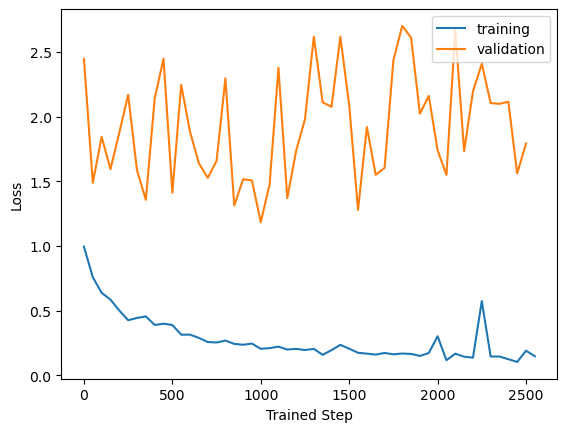

In [26]:
# Plot train/valid loss
plt.plot([item*50 for item in range(len(moving_averages))], moving_averages, label='training')
plt.plot([item*50 for item in range(len(val_loss))], val_loss, label='validation')
plt.xlabel('Trained Step')
plt.ylabel('Loss')
plt.legend()
plt.savefig(os.path.join(result_dir, 'loss_plot.png'))

output_path = os.path.join(result_dir, 'loss_plot.tiff')
plt.savefig(output_path, format='tiff', dpi=300, bbox_inches='tight', pil_kwargs={"rgb_mode": "RGB"})

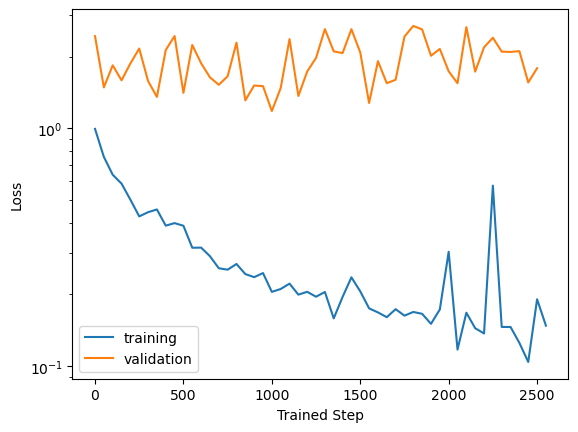

In [27]:
# Plot train/valid loss with log scale
plt.plot([item*50 for item in range(len(moving_averages))], moving_averages, label='training')
plt.plot([item*50 for item in range(len(val_loss))], val_loss, label='validation')
plt.xlabel('Trained Step')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.savefig(os.path.join(result_dir, 'loss_plot_log.png'))

output_path = os.path.join(result_dir, 'loss_plot_log.tiff')
plt.savefig(output_path, format='tiff', dpi=300, bbox_inches='tight', pil_kwargs={"rgb_mode": "RGB"})

## Evaluation on test data

In [28]:
# Load test dataframe
df = pd.read_csv(os.path.join(result_dir, 'test_df.csv'))

In [29]:
class2index = {
    'P20': 0,
    'P40': 1, 
    'P60': 2,
    'P90': 3,
    'P120': 4,
    'P150': 4,
    'P158': 4
}

In [30]:
df['gt'] = df['date'].map(class2index)

# Load prediction
gt = np.load(os.path.join(result_dir, 'gt.npy'))
pred = np.load(os.path.join(result_dir, 'pred.npy'))
pred = np.argmax(pred, axis=1)

df['load_gt'] = gt
df['pd'] = pred

assert df['gt'].equals(df['load_gt'])


In [31]:
df.head()

,path,date,case,ID,side,gt,load_gt,pd
0,./data/Histology_Images_CV/patch_images/AI_P12...,P120,AI006R,AI006,R,4,4,4
1,./data/Histology_Images_CV/patch_images/AI_P12...,P120,AI006R,AI006,R,4,4,4
2,./data/Histology_Images_CV/patch_images/AI_P12...,P120,AI006R,AI006,R,4,4,4
3,./data/Histology_Images_CV/patch_images/AI_P12...,P120,AI006R,AI006,R,4,4,4
4,./data/Histology_Images_CV/patch_images/AI_P12...,P120,AI006R,AI006,R,4,4,4


In [32]:
cf_matrix = confusion_matrix(gt, pred)

In [33]:
acc = np.sum(gt==pred) / len(gt)
f1 = f1_score(gt, pred, average='macro')

print(f"accuracy: {acc*100:.2f}%")
print(f"F1 score: {f1*100:.2f}%")

accuracy: 82.82%
F1 score: 82.07%


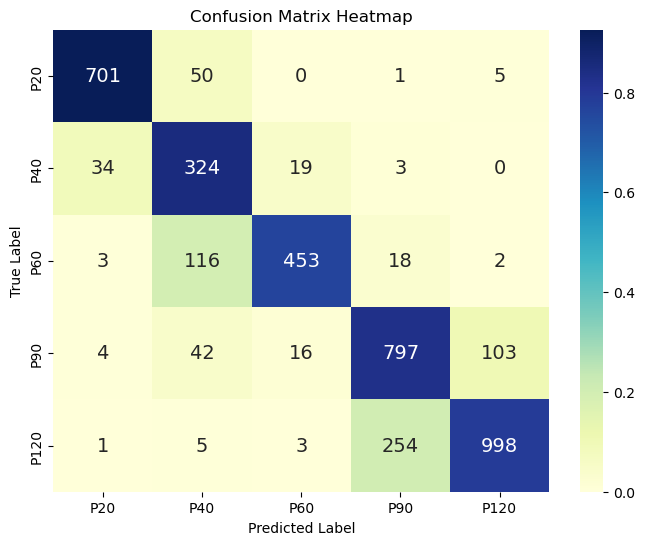

In [34]:
conf_df = pd.DataFrame(cf_matrix, index=['P20', 'P40', 'P60', 'P90', 'P120'], columns=['P20', 'P40', 'P60', 'P90', 'P120'])
accuracy_matrix = cf_matrix.astype('float') / cf_matrix.sum(axis=1)[:, np.newaxis]
accuracy_df = pd.DataFrame(accuracy_matrix, index=['P20', 'P40', 'P60', 'P90', 'P120'], columns=['P20', 'P40', 'P60', 'P90', 'P120'])

plt.figure(figsize=(8, 6))
sns.heatmap(accuracy_df, annot=conf_df, fmt="d", cmap="YlGnBu", annot_kws={"size": 14})
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(result_dir, 'conf_heatmap.png'))

In [35]:
df.to_csv(os.path.join(result_dir, 'test_df_all.csv'), index=False)

## Montage image-based Voting Prediction

In [36]:
df['montage'] = df['path'].apply(lambda x: '_'.join(x.split('_')[:-1]))

In [37]:
image_df = df.groupby('montage').agg({
    'gt': lambda x: x.mode()[0], 
    'pd': lambda x: x.mode()[0],
    'path': 'size' 
}).rename(columns={'path': 'Total Images'}).reset_index()

pd_counts = df.groupby('montage')['pd'].apply(lambda x: x.value_counts().reindex([0, 1, 2, 3, 4], fill_value=0)).unstack().reset_index()

# Merge the counts with the original grouped data
image_df = image_df.merge(pd_counts, on='montage')

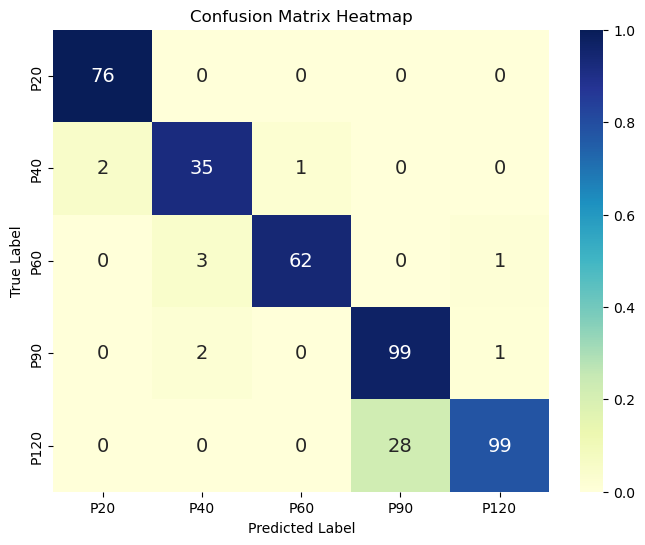

In [38]:
cf_matrix = confusion_matrix(image_df['gt'], image_df['pd'])
conf_df = pd.DataFrame(cf_matrix, index=['P20', 'P40', 'P60', 'P90', 'P120'], columns=['P20', 'P40', 'P60', 'P90', 'P120'])
accuracy_matrix = cf_matrix.astype('float') / cf_matrix.sum(axis=1)[:, np.newaxis]
accuracy_df = pd.DataFrame(accuracy_matrix, index=['P20', 'P40', 'P60', 'P90', 'P120'], columns=['P20', 'P40', 'P60', 'P90', 'P120'])

plt.figure(figsize=(8, 6))
sns.heatmap(accuracy_df, annot=conf_df, fmt="d", cmap="YlGnBu", annot_kws={"size": 14})
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(result_dir, 'conf_heatmap_montage.png'))

In [39]:
acc = np.sum(image_df['gt']==image_df['pd']) / len(image_df)
f1 = f1_score(image_df['gt'], image_df['pd'], average='macro')

print(f"accuracy: {acc*100:.2f}%")
print(f"F1 score: {f1*100:.2f}%")

accuracy: 90.71%
F1 score: 91.57%


In [40]:
name_map = {
    'gt': 'Ground True',
    'pd': 'Voting Prediction',
    0: 'P20',
    1: 'P40',
    2: 'P60',
    3: 'P90',
    4: '>=P120'
}

In [41]:
image_df['gt'] = image_df['gt'].replace(name_map)
image_df['pd'] = image_df['pd'].replace(name_map)

In [42]:
image_df = image_df.rename(columns=name_map)

In [43]:
image_df['Subject ID'] = image_df['montage'].apply(lambda x: x.split('/')[-1].split('_')[0])
image_df['Internal ID'] = image_df['montage'].apply(lambda x: x.split('/')[-1].split('_')[1])

In [44]:
image_df.head()

,montage,Ground True,Voting Prediction,Total Images,P20,P40,P60,P90,>=P120,Subject ID,Internal ID
0,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,0,10,AI006R,1
1,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,0,10,AI006R,10
2,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,0,10,AI006R,11
3,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,0,10,AI006R,12
4,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,1,9,AI006R,13


In [45]:
def find_ori_img_path(row):
    date = row['montage'].split('/')[-2]
    subject_id = row['Subject ID']
    given_id = row['Internal ID']
    
    target = path_df[(path_df['date'] == date) &
                    (path_df['case_id'] == subject_id) &
                    (path_df['given_id'] == int(given_id))]
    
    assert len(target) == 1, f"Multiple or no matches found for: {date}, {subject_id}, {given_id}: {target}"
    return target['ori_img_path'].values[0]

In [46]:
image_df['Original Image Path'] = image_df.apply(find_ori_img_path, axis=1)

image_df.head()

,montage,Ground True,Voting Prediction,Total Images,P20,P40,P60,P90,>=P120,Subject ID,Internal ID,Original Image Path
0,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,0,10,AI006R,1,AI006R36/AI_AI006R36_6_Nasal_Bottom_Merged_RAW...
1,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,0,10,AI006R,10,AI006R16/AI_AI006R16_3_Nasal_Bottom_Merged_RAW...
2,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,0,10,AI006R,11,AI006R16/AI_AI006R16_7_Nasal_Bottom_Merged_RAW...
3,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,0,10,AI006R,12,AI006R16/AI_AI006R16_1_Nasal_Bottom_Merged_RAW...
4,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,1,9,AI006R,13,AI006R16/AI_AI006R16_2_Nasal_Bottom_Merged_RAW...


In [47]:
image_df['Correct'] = image_df['Ground True'] == image_df['Voting Prediction']

In [48]:
image_df

,montage,Ground True,Voting Prediction,Total Images,P20,P40,P60,P90,>=P120,Subject ID,Internal ID,Original Image Path,Correct
0,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,0,10,AI006R,1,AI006R36/AI_AI006R36_6_Nasal_Bottom_Merged_RAW...,True
1,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,0,10,AI006R,10,AI006R16/AI_AI006R16_3_Nasal_Bottom_Merged_RAW...,True
2,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,0,10,AI006R,11,AI006R16/AI_AI006R16_7_Nasal_Bottom_Merged_RAW...,True
3,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,0,10,AI006R,12,AI006R16/AI_AI006R16_1_Nasal_Bottom_Merged_RAW...,True
4,./data/Histology_Images_CV/patch_images/AI_P12...,>=P120,>=P120,10,0,0,0,1,9,AI006R,13,AI006R16/AI_AI006R16_2_Nasal_Bottom_Merged_RAW...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,./data/Histology_Images_CV/patch_images/AI_P90...,P90,P90,10,0,0,0,10,0,AI029R,5,AI029R16/AI029R16-6.tif,True
405,./data/Histology_Images_CV/patch_images/AI_P90...,P90,P90,9,0,0,0,8,1,AI029R,6,AI029R16/AI029R16-3.tif,True
406,./data/Histology_Images_CV/patch_images/AI_P90...,P90,P90,10,0,0,0,9,1,AI029R,7,AI029R16/AI029R16-1.tif,True
407,./data/Histology_Images_CV/patch_images/AI_P90...,P90,P90,10,0,0,0,10,0,AI029R,8,AI029R6/AI029R6-7.tif,True


In [49]:
image_df.to_csv(os.path.join(result_dir, 'test_df_montagebase.csv'), index=False)

## Case-based Voting Prediction

In [50]:
case_df = df.groupby('case').agg({
    'gt': lambda x: x.mode()[0], 
    'pd': lambda x: x.mode()[0],
    'path': 'size' 
}).rename(columns={'path': 'Total Images'}).reset_index()

pd_counts = df.groupby('case')['pd'].apply(lambda x: x.value_counts().reindex([0, 1, 2, 3, 4], fill_value=0)).unstack().reset_index()

# Merge the counts with the original grouped data
case_df = case_df.merge(pd_counts, on='case')

In [51]:
case_df = case_df.rename(columns={
    'gt': 'Ground True',
    'pd': 'Voting Prediction',
    0: 'P20',
    1: 'P40',
    2: 'P60',
    3: 'P90',
    4: '>=P120'
})

In [52]:
case_df

,case,Ground True,Voting Prediction,Total Images,P20,P40,P60,P90,>=P120
0,AI006R,4,4,471,0,0,0,3,468
1,AI017L,2,2,32,0,9,22,0,1
2,AI017R,2,2,560,3,107,431,18,1
3,AI018L,3,3,374,1,40,11,305,17
4,AI018R,3,3,300,0,2,4,259,35
5,AI021L,4,4,310,1,1,1,93,214
6,AI021R,4,4,480,0,4,2,158,316
7,AI023R,1,1,380,34,324,19,3,0
8,AI029R,3,3,288,3,0,1,233,51
9,AI036L,0,0,290,269,19,0,1,1


In [53]:
case_df.to_csv(os.path.join(result_dir, 'test_df_casebase.csv'), index=False)

## Subject-based Voting Prediction

In [54]:
subject_df = df.groupby('ID').agg({
    'gt': lambda x: x.mode()[0], 
    'pd': lambda x: x.mode()[0],
    'path': 'size' 
}).rename(columns={'path': 'Total Images'}).reset_index()

pd_counts = df.groupby('ID')['pd'].apply(lambda x: x.value_counts().reindex([0, 1, 2, 3, 4], fill_value=0)).unstack().reset_index()

# Merge the counts with the original grouped data
subject_df = subject_df.merge(pd_counts, on='ID')

In [55]:
subject_df = subject_df.rename(columns={
    'gt': 'Ground True',
    'pd': 'Voting Prediction',
    0: 'P20',
    1: 'P40',
    2: 'P60',
    3: 'P90',
    4: '>=P120'
})

In [56]:
subject_df

,ID,Ground True,Voting Prediction,Total Images,P20,P40,P60,P90,>=P120
0,AI006,4,4,471,0,0,0,3,468
1,AI017,2,2,592,3,116,453,18,2
2,AI018,3,3,674,1,42,15,564,52
3,AI021,4,4,790,1,5,3,251,530
4,AI023,1,1,380,34,324,19,3,0
5,AI029,3,3,288,3,0,1,233,51
6,AI036,0,0,757,701,50,0,1,5


In [57]:
subject_df.to_csv(os.path.join(result_dir, 'test_df_subjectbase.csv'), index=False)
